In [123]:
import pandas as pd
import numpy as np
from nbconvert import export

In [124]:
#Loading in the roads data file
df1 = pd.read_csv('../data/_roads3.csv')
# print(df1.head())

#Filtering on only the N1 road
dfN1 = df1[df1['road'] == 'N1']

In [125]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage
source_val = dfN1['chainage'].min()
sink_val = dfN1['chainage'].max()
source_row = dfN1[dfN1['chainage'] == source_val].head(1)
sink_row = dfN1[dfN1['chainage'] == sink_val].head(1)

In [126]:
#Creating a new DataFrame with the source and sink
df_proc = pd.concat([source_row, sink_row]).drop_duplicates(subset=['chainage', 'lrp']).sort_values('chainage').reset_index(drop=True)

In [127]:
df_proc

,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."


In [128]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('../data/BMMS_overview.xlsx')

In [129]:
#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'] == 'N1']

In [130]:
bridges_BMMS.head(20)

,road,name,LRPName,length,chainage,lat,lon,condition
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A


In [131]:
bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()
bridges_BMMS['lat_round'] = bridges_BMMS['lat'].round(4)
bridges_BMMS['lon_round'] = bridges_BMMS['lon'].round(4)

In [132]:
bridges_BMMS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        787 non-null    object 
 1   name        787 non-null    object 
 2   LRPName     787 non-null    object 
 3   length      787 non-null    float64
 4   chainage    787 non-null    float64
 5   lat         787 non-null    float64
 6   lon         787 non-null    float64
 7   condition   787 non-null    object 
 8   name_clean  787 non-null    object 
 9   lat_round   787 non-null    float64
 10  lon_round   787 non-null    float64
dtypes: float64(6), object(5)
memory usage: 73.8+ KB


In [133]:
df_unique = bridges_BMMS.drop_duplicates(subset=['chainage', 'lat_round', 'lon_round'], keep='first')

In [134]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 628 entries, 0 to 19382
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   road        628 non-null    object 
 1   name        628 non-null    object 
 2   LRPName     628 non-null    object 
 3   length      628 non-null    float64
 4   chainage    628 non-null    float64
 5   lat         628 non-null    float64
 6   lon         628 non-null    float64
 7   condition   628 non-null    object 
 8   name_clean  628 non-null    object 
 9   lat_round   628 non-null    float64
 10  lon_round   628 non-null    float64
dtypes: float64(6), object(5)
memory usage: 58.9+ KB


In [135]:
df_unique.reset_index(drop=True, inplace=True)
df_unique

,road,name,LRPName,length,chainage,lat,lon,condition,name_clean,lat_round,lon_round
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.,23.6987,90.4589
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.,23.6947,90.4878
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.,23.7051,90.5232
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT,23.6944,90.5376
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT,23.6943,90.5377
...,...,...,...,...,...,...,...,...,...,...,...
623,N1,MORICHIA,LRP394a,11.20,397.591,21.321109,92.088884,D,MORICHIA,21.3211,92.0889
624,N1,SHAPUR STEEL BEAM AND RCC SLAB,LRP396b,61.30,400.460,21.299745,92.097477,D,SHAPURSTEELBEAMANDRCCSLAB,21.2997,92.0975
625,N1,Balukhali Boro Bridge,LRP413b,15.40,417.290,21.188892,92.165877,D,BALUKHALIBOROBRIDGE,21.1889,92.1659
626,N1,Kata Khali Bridge,LRP421a,12.30,424.577,21.137612,92.168059,D,KATAKHALIBRIDGE,21.1376,92.1681


In [136]:
to_delete = []
for i, row in df_unique.iterrows():
    if i == 0:
        continue
    else:
        lat_lon_check = False
        length_check = False
        lrp_check = False
        lat_rounded = round(row['lat_round'],3)
        lon_rounded = round(row['lon_round'],3)
        if lat_rounded == round(df_unique.iloc[i-1]['lat_round'],3) and lon_rounded == round(df_unique.iloc[i-1]['lon_round'],3):
            lat_lon_check = True
        if float(row['length']) - float(df_unique.iloc[i-1]['length']) < 0.5:
            length_check = True
        if row['LRPName'][:6] == df_unique.iloc[i-1]['LRPName'][:6]:
            lrp_check = True
        if lat_lon_check and length_check and lrp_check:
            to_delete.append(i)
            
print(to_delete)
df_unique.loc[to_delete]

[4, 7, 28, 314, 370, 570]


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean,lat_round,lon_round
4,N1,ADUPUR CULVERT,LRP010c,6.3,10.897,23.694302,90.537707,A,ADUPURCULVERT,23.6943,90.5377
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.1,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT,23.6883,90.5486
28,N1,NOYAPARA,LRP033b,5.2,32.796,23.547625,90.669192,A,NOYAPARA,23.5476,90.6692
314,N1,NORTH-CONIAPARA,LRP389b,1.3,392.619,21.359728,92.079803,A,NORTH-CONIAPARA,21.3597,92.0798
370,N1,KHANGOR PRAMARY (2),LRP429c,1.2,432.924,21.086500,92.215111,A,KHANGORPRAMARY(2),21.0865,92.2151
570,N1,PANCHARA SLAB CULVERT,LRP385d,1.8,388.956,21.385641,92.070454,C,PANCHARASLABCULVERT,21.3856,92.0705


In [137]:
df_unique['model_type'] = 'bridge'



export_df = df_unique[['road', 'LRPName', 'model_type', 'name', 'lat', 'lon','length', 'condition', 'chainage']]
export_df.rename(columns={'LRPName': 'id'}, inplace=True)
export_df

C:\Users\lieke\AppData\Local\Temp\ipykernel_28324\1181640424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['model_type'] = 'bridge'
C:\Users\lieke\AppData\Local\Temp\ipykernel_28324\1181640424.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  export_df.rename(columns={'LRPName': 'id'}, inplace=True)


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
1,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A,4.925
2,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
3,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880
4,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897
...,...,...,...,...,...,...,...,...,...
623,N1,LRP394a,bridge,MORICHIA,21.321109,92.088884,11.20,D,397.591
624,N1,LRP396b,bridge,SHAPUR STEEL BEAM AND RCC SLAB,21.299745,92.097477,61.30,D,400.460
625,N1,LRP413b,bridge,Balukhali Boro Bridge,21.188892,92.165877,15.40,D,417.290
626,N1,LRP421a,bridge,Kata Khali Bridge,21.137612,92.168059,12.30,D,424.577


In [138]:
df_proc['model_type'] = 'source'
df_proc['length'] = 0
df_proc['condition'] = None
df_proc = df_proc[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_proc.rename(columns={'lrp':'id'}, inplace=True)


C:\Users\lieke\AppData\Local\Temp\ipykernel_28324\676524970.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_proc.rename(columns={'lrp':'id'}, inplace=True)


In [139]:
df_proc

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,source,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254


In [140]:
final_df = pd.DataFrame(columns=['road','id','model_type','name','lat','lon','length', 'condition', 'chainage'])
source = df_proc.iloc[[0]]
sink = df_proc.iloc[[-1]]
final_df = pd.concat([source, export_df, sink], ignore_index=True)
final_df = final_df.sort_values('chainage').reset_index(drop=True)
final_df

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800
2,N1,LRP004b,bridge,.,23.694664,90.487775,6.60,A,4.925
3,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976
4,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543
...,...,...,...,...,...,...,...,...,...
625,N1,LRP455a,bridge,TEKNAF NAITANG RCC GIDER BRIDGE,20.890158,92.295718,37.30,B,458.799
626,N1,LRP456a,bridge,BUS STAND TEKNAF BOX CULVERT,20.884567,92.298716,1.50,A,459.681
627,N1,LRP456b,bridge,BUS STAND TEKNAF BOX CULVERT,20.883070,92.298163,1.50,C,459.866
628,N1,LRP456c,bridge,YAKNAT BRIDGE,20.880985,92.297777,35.90,C,460.113


In [141]:
# final_df_with_links = pd.DataFrame(columns=['road','id','model_type','name','lat','lon','length', 'condition'])
# for j, row in final_df.iterrows():
#     if row['model_type'] == 'sink':
#         break
#     elif row['model_type'] == 'source':
#         final_df_with_links.loc[len(final_df_with_links)] = row
#     else:
#         lat_link = row['lat'] - (row['lat'] - final_df.iloc[j-1]['lat']) / 2
#         lon_link = row['lon'] - (row['lon'] - final_df.iloc[j-1]['lon']) / 2
#         length = 0
#         condition = None
#         link = pd.Series({'road': 'N1', 'id': 'LRPxxx', 'model_type': 'link', 'name': 'LRP', 'lat': lat_link, 'lon': lon_link, 'length': length, 'condition': condition})
#         final_df_with_links.loc[len(final_df_with_links)] = link
#         final_df_with_links.loc[len(final_df_with_links)] = row
#
# final_df_with_links.head(20)


In [142]:
final_df_with_links = []

for j in range(len(final_df)):
    row = final_df.iloc[j]

    if row['model_type'] == 'source':
        final_df_with_links.append(row)
        continue

    if row['model_type'] == 'sink':
        final_df_with_links.append(row)
        break

    prev = final_df.iloc[j-1]

    lat_link = (row['lat'] + prev['lat']) / 2
    lon_link = (row['lon'] + prev['lon']) / 2

    link_length = (row['chainage'] - prev['chainage'])* 1000

    link = {
        'road': row['road'],
        'id': None,
        'model_type': 'link',
        'name': 'Link',
        'lat': lat_link,
        'lon': lon_link,
        'length': link_length,
        'condition': None,
        'chainage': (row['chainage'] + prev['chainage']) / 2
    }

    final_df_with_links.append(pd.Series(link))
    final_df_with_links.append(row)
final_df_with_links = (
    pd.DataFrame(final_df_with_links)
      .reset_index(drop=True)
      .drop(columns='chainage')
)

final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition
0,N1,100001,source,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None
1,N1,100002,link,Link,23.702383,90.451097,1800.00,None
2,N1,100003,bridge,.,23.698739,90.458861,11.30,A
3,N1,100004,link,Link,23.696701,90.473318,3125.00,None
4,N1,100005,bridge,.,23.694664,90.487775,6.60,A
5,N1,100006,link,Link,23.699862,90.505495,4051.00,None
6,N1,100007,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A
7,N1,100008,link,Link,23.700730,90.529157,1567.00,None
8,N1,100009,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B
9,N1,100010,link,Link,23.695395,90.536337,337.00,None


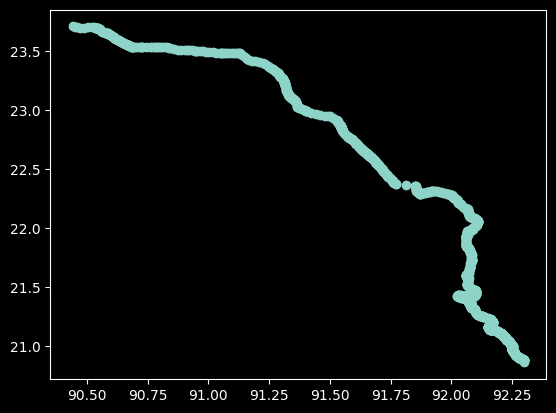

In [143]:
import matplotlib.pyplot as plt

plt.scatter(final_df_with_links['lon'], final_df_with_links['lat'])
plt.show()

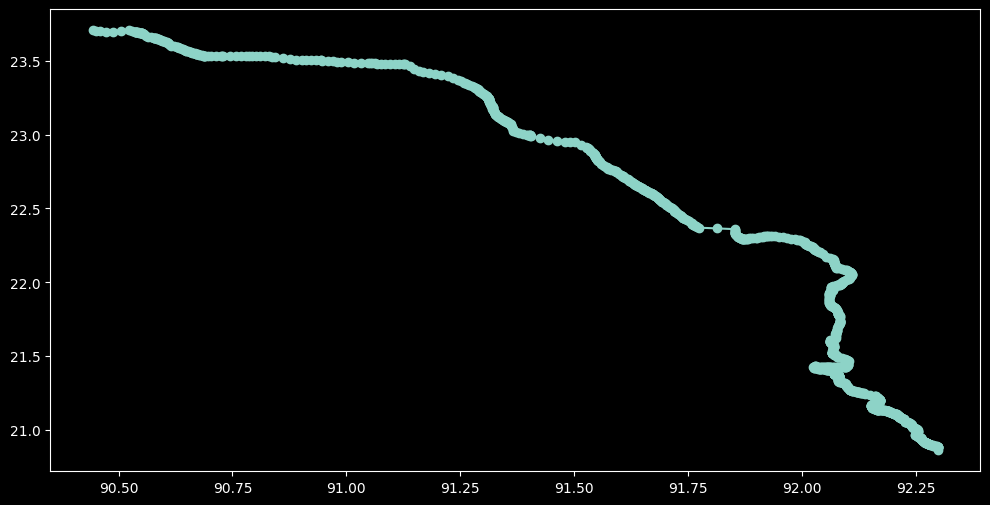

In [144]:
plt.figure(figsize=(12,6))
plt.plot(final_df_with_links['lon'], final_df_with_links['lat'], marker='o')
plt.show()

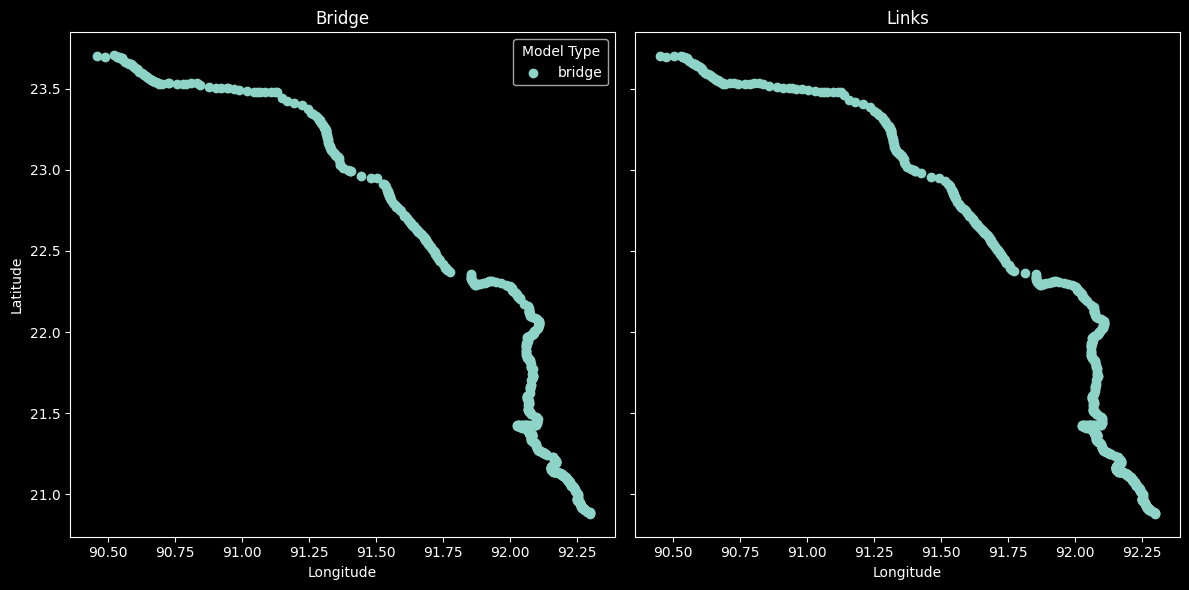

In [147]:
# import matplotlib.pyplot as plt
#
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
#
# # Bridge plot
# bridge_df = final_df_with_links[final_df_with_links['model_type'] == 'bridge']
# for model_type, group in bridge_df.groupby('model_type'):
#     axes[0].scatter(group['lon'], group['lat'], label=model_type)
#
# axes[0].set_title("Bridge")
# axes[0].set_xlabel("Longitude")
# axes[0].set_ylabel("Latitude")
# axes[0].legend(title="Model Type")
#
# # Links plot
# links_df = final_df_with_links[final_df_with_links['model_type'] == 'link']
# for model_type, group in links_df.groupby('model_type'):
#     axes[1].scatter(group['lon'], group['lat'], label=model_type)
#
# axes[1].set_title("Links")
# axes[1].set_xlabel("Longitude")
#
# plt.tight_layout()
# plt.show()

In [147]:
final_df_with_links.to_csv('data_N1.csv')